# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Adult Census Income dataset (also known as the Adult dataset or Census Income dataset) is a classic benchmark for binary classification tasks in social sciences and machine learning. It was designed to predict whether an individual’s annual income exceeds $50,000 based on demographic and employment‑related features extracted from the 1994 United States Census Bureau database. The dataset was created by Barry Becker and Ronny Kohavi (Data Mining and Visualization, Silicon Graphics) and has been widely used for evaluating classification algorithms, including logistic regression, decision trees, support vector machines, and fairness‑aware models.
We used the Adult dataset, which contains 48 785 instances with a 16,08 % anomaly rate. It comprises 5 numerical and 8 categorical features ('education-num' was removed, as it duplicates 'education'). The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 622 instances for finetuning, of which 100 were anomalies, and the same number (622  instances, 100 anomalies) for testing.

In [3]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Loading train (32,561) + test (16,281)
train = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
                    names=columns, na_values=' ?', skipinitialspace=True)
test = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
                   names=columns, na_values=' ?', skipinitialspace=True, skiprows=1)
df_raw = pd.concat([train, test], ignore_index=True)

print(f"Size: {df_raw.shape}")

Size: (48842, 15)


# Preprocessing

In [4]:
df_raw.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df_raw = df_raw.drop(columns=['education-num'])
df_raw.shape

(48842, 14)

In [6]:
X = preprocess_dataset(df_raw.drop(columns=['income']))
y = (df_raw['income'] == '>50K').astype(int).loc[X.index].squeeze()
y = replace_target(y)

No constant features were found
Size after preprocessing: (48785, 13)


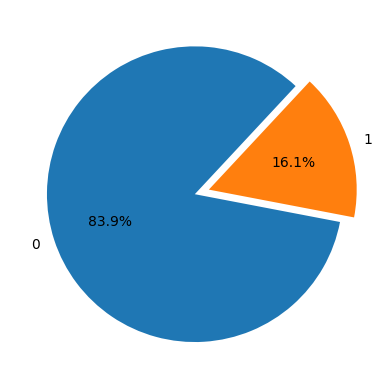

In [7]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [8]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 40947
Класс 1 : 7838


In [9]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
8,sex,"[Male, Female]",2,object
7,race,"[White, Black, Asian-Pac-Islander, Amer-Indian...",5,object
6,relationship,"[Not-in-family, Husband, Wife, Own-child, Unma...",6,object
4,marital-status,"[Never-married, Married-civ-spouse, Divorced, ...",7,object
1,workclass,"[State-gov, Self-emp-not-inc, Private, Federal...",9,object
5,occupation,"[Adm-clerical, Exec-managerial, Handlers-clean...",15,object
3,education,"[Bachelors, HS-grad, 11th, Masters, 9th, Some-...",16,object
12,native-country,"[United-States, Cuba, Jamaica, India, ?, Mexic...",42,object
0,age,"[39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 30, 2...",74,int64
11,hours-per-week,"[40, 13, 16, 45, 50, 80, 30, 35, 60, 20, 52, 4...",96,int64


In [10]:
num_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [11]:
for col in cat_cols:
    X[col] = X[col].astype(str).replace('?', 'Unknown')